In [1]:
import numpy as np
import cv2 
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms,models
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [5]:
main_path = "/kaggle/input/pets-facial-expression-dataset/Master Folder/"
train_path = main_path+"train/"
val_path = main_path+"valid/"
test_path = main_path+"test/"
img_folder = ImageFolder(root=train_path)


# Class Counts and Different Image Sizes

In [6]:
class_counts = {}
image_sizes = {}
for img, img_cls in img_folder:
    if img.size not in image_sizes:
        image_sizes[img.size] = 0
    image_sizes[img.size] += 1
    
    if img_cls not in class_counts:
        class_counts[img_cls] = 0

    class_counts[img_cls] += 1

print(class_counts)
print(image_sizes)

{0: 250, 1: 250, 2: 250, 3: 250}
{(224, 224): 633, (179, 179): 367}


# Augmentations & Transforms

In [7]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

data_transforms = {
    'train':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.01),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ]),
    'validation':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        normalize
    ]),
}

# Dataset & Dataloader

In [8]:
import os
from PIL import Image
from torch.utils.data import Dataset

class PetDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))  # Get class names
        self.file_paths = []
        self.labels = []

        for idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for file_name in os.listdir(class_dir):
                self.file_paths.append(os.path.join(class_dir, file_name))
                self.labels.append(idx)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]

        # Load image and apply transformations
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [9]:
train_dataset = PetDataset(train_path,data_transforms['train'])
val_dataset = PetDataset(val_path,data_transforms['validation'])

In [10]:
train_loader = DataLoader(train_dataset,batch_size = 16,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size = 16,shuffle=False)

Feature batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])


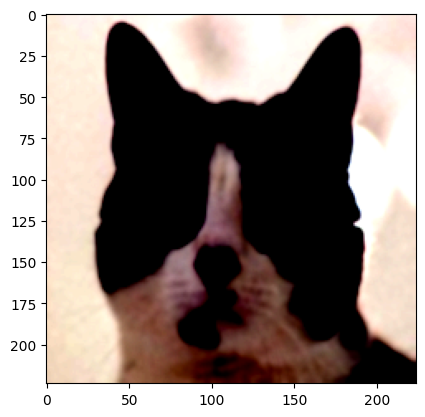

Label: 2


In [11]:
import matplotlib.pyplot as plt

# Get a batch of data from the train_loader
batch = next(iter(train_loader))

# Print the shape of images and labels in the batch
print(f"Feature batch shape: {batch[0].size()}")  # batch[0] contains the image tensor
print(f"Labels batch shape: {batch[1].size()}")   # batch[1] contains the label tensor

# Select the 3rd image in the batch and remove the channel dimension (squeeze)
img = batch[0][3].squeeze()

# Get the label for the 3rd image
label = batch[1][3]

# Display the image
plt.imshow(img.permute(1, 2, 0))  # permute from (C, H, W) to (H, W, C) for correct display
plt.show()

# Print the label
print(f"Label: {label}")


# Model

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [13]:
train_dataset = PetDataset(train_path, data_transforms['train'])
val_dataset = PetDataset(val_path, data_transforms['validation'])

# Check dataset output
sample_image, sample_label = train_dataset[0]
print(f"Sample Image Type: {type(sample_image)}, Shape: {sample_image.shape}")
print(f"Sample Label: {sample_label}")

# Check DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
for inputs, labels in train_loader:
    print(f"Batch Inputs Type: {type(inputs)}, Shape: {inputs.shape}")
    print(f"Batch Labels: {labels}")
    break

Sample Image Type: <class 'torch.Tensor'>, Shape: torch.Size([3, 224, 224])
Sample Label: 0
Batch Inputs Type: <class 'torch.Tensor'>, Shape: torch.Size([16, 3, 224, 224])
Batch Labels: tensor([0, 2, 3, 0, 3, 2, 3, 0, 0, 2, 3, 0, 1, 0, 3, 0])


In [22]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.metrics import accuracy_score


num_classes = len(train_dataset.classes)

# Load pre-trained ResNet18
model = models.resnet18(pretrained=True)

# Modify the fully connected layer for 4 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Modify the last layer for our task
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

import matplotlib.pyplot as plt

# Training and Validation Loop with Loss Tracking
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=100):
    train_losses = []
    val_losses = []
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Statistics
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total
        train_losses.append(train_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_losses.append(val_loss / len(val_loader))

         # Save the model if validation accuracy improves
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "best_val_acc": best_val_acc,
            }, "best_model_checkpoint.pth")
            print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")


        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_acc:.4f}")

    return train_losses, val_losses

# Train the model and track losses
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=100)



# Save the model
#torch.save(model.state_dict(), "ResNet18_transfer_learning.pth")


New best model saved with validation accuracy: 0.5000
Epoch 1/100
Train Loss: 0.9962, Train Accuracy: 0.5850
Validation Loss: 0.9208, Validation Accuracy: 0.5000
New best model saved with validation accuracy: 0.5556
Epoch 2/100
Train Loss: 0.3398, Train Accuracy: 0.9190
Validation Loss: 1.1063, Validation Accuracy: 0.5556
Epoch 3/100
Train Loss: 0.1510, Train Accuracy: 0.9660
Validation Loss: 1.2356, Validation Accuracy: 0.4444
Epoch 4/100
Train Loss: 0.0620, Train Accuracy: 0.9890
Validation Loss: 1.4247, Validation Accuracy: 0.4722
Epoch 5/100
Train Loss: 0.0374, Train Accuracy: 0.9950
Validation Loss: 1.4400, Validation Accuracy: 0.5278
Epoch 6/100
Train Loss: 0.0231, Train Accuracy: 0.9990
Validation Loss: 1.6027, Validation Accuracy: 0.5278
Epoch 7/100
Train Loss: 0.0324, Train Accuracy: 0.9960
Validation Loss: 1.6693, Validation Accuracy: 0.5278
Epoch 8/100
Train Loss: 0.0307, Train Accuracy: 0.9910
Validation Loss: 2.0052, Validation Accuracy: 0.5000
Epoch 9/100
Train Loss: 0.05

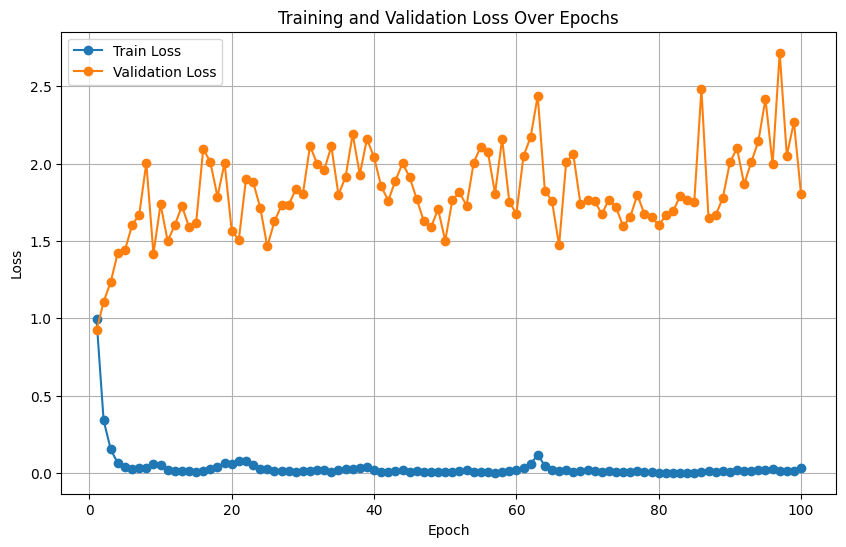

In [23]:
# Plot Training and Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()

In [24]:
total_samples = 0

# Iterate through the DataLoader and count samples for training set
for image, label in train_loader:
    total_samples += image.size(0)  # `image` contains the input data (images)

print("Sample train =", total_samples)

total_samples = 0

# Iterate through the DataLoader and count samples for validation set
for image, label in val_loader:
    total_samples += image.size(0)  # `image` contains the input data (images)

print("Sample val =", total_samples)


Sample train = 1000
Sample val = 36


In [30]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from torchvision.models import ResNet18_Weights

# Define transformations for the test dataset
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Assuming you have a test dataset class similar to PetDataset
test_dataset = PetDataset(root_dir=test_path, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load the saved checkpoint
checkpoint = torch.load("best_model_checkpoint.pth")
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)  # Initialize the same model architecture
num_classes = len(test_dataset.classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model.load_state_dict(checkpoint["model_state_dict"])  # Load model weights
model = model.to(device)

# Set the model to evaluation mode
model.eval()

# Perform inference and calculate accuracy
test_preds = []
test_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)  # Get predicted class indices
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Obtain predictions and labels from the test loop
#test_preds, test_labels, test_loss = test_loop(model, test_loader)

# Calculate metrics
test_accuracy = accuracy_score(test_labels, test_preds)

precision = precision_score(test_labels, test_preds, average='macro')  # or 'weighted' for weighted average
recall = recall_score(test_labels, test_preds, average='macro')
f1 = f1_score(test_labels, test_preds, average='macro')
conf_matrix = confusion_matrix(test_labels, test_preds)

# Print metrics
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds))


Test Accuracy: 0.5526
Precision (macro): 0.5945
Recall (macro): 0.5098
F1-score (macro): 0.5125
Confusion Matrix:
[[6 1 3 0]
 [0 1 5 0]
 [2 0 8 1]
 [2 0 3 6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        10
           1       0.50      0.17      0.25         6
           2       0.42      0.73      0.53        11
           3       0.86      0.55      0.67        11

    accuracy                           0.55        38
   macro avg       0.59      0.51      0.51        38
weighted avg       0.61      0.55      0.54        38

